# Pairs Trading Research — Walkthrough

This notebook walks the pairs-trading research project end-to-end using
the artifacts already committed under `results/`. No fitting, no
backtesting, and no new computation runs here — every figure and table
below is loaded from disk. The narrative tracks the project's four
sessions and the six findings (F1–F6) discussed in the README and the
longer writeup at `docs/writeup.md`.

Read this notebook end-to-end if you want the project at moderate
depth: deeper than the README skim, lighter than the writeup or the
source code.

## 1. Setup

Imports and load every CSV output from `results/` into named DataFrames.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown

RESULTS = Path('..') / 'results'

pairs_ranked = pd.read_csv(RESULTS / '01_pairs_ranked.csv')
pairs_ranked_full = pd.read_csv(RESULTS / '01_pairs_ranked_full.csv')
ols_metrics = pd.read_csv(RESULTS / '02_pair_metrics.csv')
kalman_metrics = pd.read_csv(RESULTS / '03_kalman_pair_metrics.csv')
portfolio_metrics = pd.read_csv(RESULTS / '04_pairs_portfolio_metrics.csv')

pd.set_option('display.float_format', lambda v: f'{v:.4f}' if pd.notna(v) else '   nan')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

print(f'01_pairs_ranked         : {pairs_ranked.shape}')
print(f'01_pairs_ranked_full    : {pairs_ranked_full.shape}')
print(f'02_pair_metrics         : {ols_metrics.shape}')
print(f'03_kalman_pair_metrics  : {kalman_metrics.shape}')
print(f'04_pairs_portfolio      : {portfolio_metrics.shape}')

01_pairs_ranked         : (2, 14)
01_pairs_ranked_full    : (24, 14)
02_pair_metrics         : (8, 18)
03_kalman_pair_metrics  : (11, 21)
04_pairs_portfolio      : (9, 18)


## 2. The research question and the universe

We ask: on a recent ten-year window of US equities, with a methodologically
careful pipeline (multiple-testing-corrected cointegration tests, a
held-out validation window, explicit transaction costs, no in-sample
tuning), what survives?

The data is split three ways:

| window | dates | role |
|---|---|---|
| Selection  | 2015-01-01 to 2020-12-31 | pair selection, hedge-ratio fitting |
| Validation | 2021-01-01 to 2022-12-31 | every backtest in the project |
| Holdout    | 2023-01-01 to 2024-12-31 | reserved, untouched |

An initial sector-clustered S&P 500 single-stock scan over 2015–2020
produced **zero** FDR-survivors. We then re-ran the identical scan
on a structural universe — share classes, same-index ETFs,
same-underlying commodity ETFs, sector overlaps, and an explicit
negative control — to verify the pipeline could detect cointegration
where it structurally exists. That scan is what the rest of this
notebook works from.

## 3. Cointegration scan

The strict-filtered output of `scripts/01_cointegration_scan.py`:
FDR-Benjamini-Hochberg-adjusted p ≤ 0.05 AND AR(1) half-life ≤ 60
days. Two pairs survive.

In [2]:
show_cols = [
    'group', 'asset_y', 'asset_x', 'pvalue', 'pvalue_adjusted',
    'pvalue_first_half', 'pvalue_second_half',
    'hedge_ratio', 'half_life', 'johansen_cointegrated',
]
pairs_ranked[show_cols]

,group,asset_y,asset_x,pvalue,pvalue_adjusted,pvalue_first_half,pvalue_second_half,hedge_ratio,half_life,johansen_cointegrated
0,Same-index ETFs,SPY,VOO,0.0001,0.0007,0.0937,0.0018,0.9940,0.8659,True
1,Share classes,GOOG,GOOGL,0.0312,0.0312,0.2945,0.0374,1.0340,25.4372,True


Reading the table: SPY/VOO is statistically tight (adjusted p≈7×10⁻⁴)
but has a half-life under one day — too fast for a 5 bps round-trip
cost regime, as session 02 will demonstrate on a similar pair
(GLD/IAU). GOOG/GOOGL is the tradable pair: half-life 25 days,
Johansen-confirmed.

Sub-window stability: GOOG/GOOGL has p_first_half=0.29 and
p_second_half=0.04. The C-class GOOG share was created in April 2014
and the spread had not yet accumulated meaningful idiosyncratic
variance in the first half of the selection window. The full-window
Engle-Granger test and the Johansen test both pass; we keep the pair
and flag the sub-window pattern in the writeup.

The control diagnostics from the scan (positive: GOOG/GOOGL passes;
negative: SPY/GLD fails) are the pipeline-validation evidence.

In [3]:
controls = pairs_ranked_full[
    pairs_ranked_full[['asset_y', 'asset_x']]
    .apply(tuple, axis=1)
    .isin([('GOOG', 'GOOGL'), ('GLD', 'SPY')])
]
controls[['asset_y', 'asset_x', 'pvalue', 'pvalue_adjusted',
          'half_life', 'johansen_cointegrated']]

,asset_y,asset_x,pvalue,pvalue_adjusted,half_life,johansen_cointegrated
1,GOOG,GOOGL,0.0312,0.0312,25.4372,True
2,GLD,SPY,0.3375,0.3375,98.6295,False


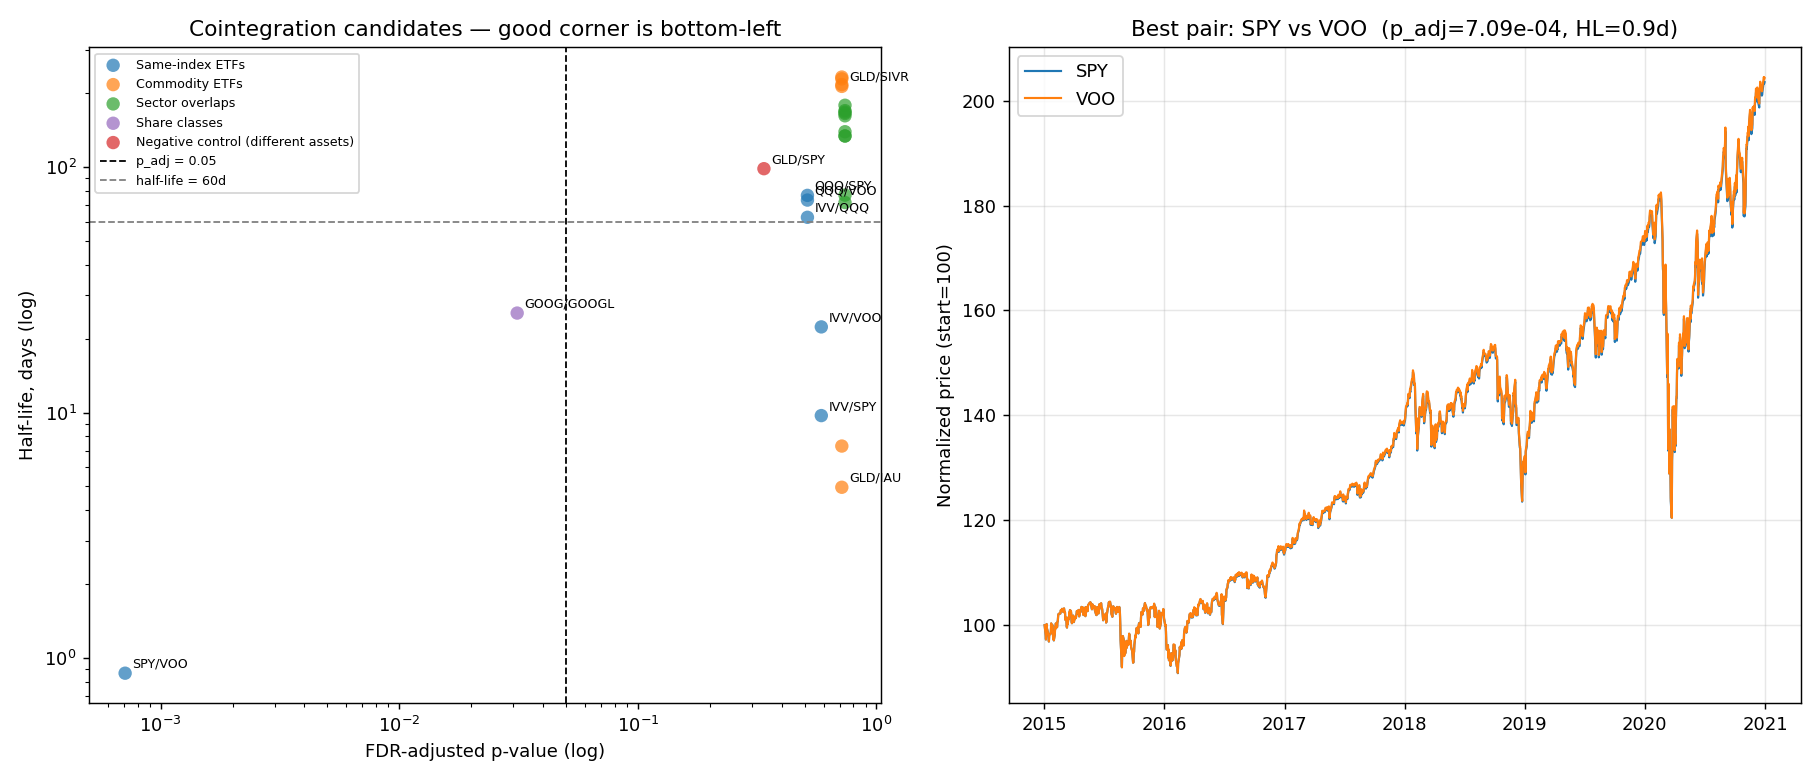

In [4]:
Image(str(RESULTS / '01_pair_candidates.png'))

Left panel: each point is one pair, FDR-adjusted p-value (log) on the
x-axis, half-life (log) on the y-axis. The good corner is bottom-left
(low p, fast mean-reversion). The black dashed line at p=0.05 and the
grey dashed line at HL=60d mark the gating thresholds. Right panel:
GOOG and GOOGL log-prices normalised to 100 at the start of the
selection window — the visual case for cointegration is that the two
lines stay close throughout.

## 4. OLS pair backtest (session 02)

Frozen β on selection-window log-prices, rolling z-score with window
= max(2·HL, 20) days, entry at |z|>2, exit at |z|<0.5, hard stop at
|z|>4, 5 bps round-trip cost, DTB3 cash accrual on idle days,
`signal_lag=1`. Ran through Backtest-Engine's `run_backtest`.

Per-pair metrics on the validation window (2021–2022):

In [5]:
ols_view = ols_metrics[[
    'pair', 'label', 'beta', 'half_life', 'sharpe', 'sharpe_gross',
    'ann_return', 'ann_vol', 'max_drawdown', 'turnover_ann',
    'mean_gross_exposure', 'pct_days_active',
]]
ols_view

,pair,label,beta,half_life,sharpe,sharpe_gross,ann_return,ann_vol,max_drawdown,turnover_ann,mean_gross_exposure,pct_days_active
0,GOOG/GOOGL,GOOG/GOOGL strategy (net),1.0340,25.5311,0.3684,1.2284,0.0174,0.0185,-0.0183,31.6521,0.6847,0.3367
1,GOOG/GOOGL,GOOG/GOOGL long-GOOG B&H,1.0340,25.5311,0.1575,0.1583,0.0631,0.3224,-0.4460,0.5020,0.9980,0.9980
2,GOOG/GOOGL,GOOG/GOOGL static-spread,1.0340,25.5311,-0.2529,-0.2405,-0.0004,0.0428,-0.0543,1.0210,2.0299,0.9980
3,GOOG/GOOGL,GOOG/GOOGL cash-only,1.0340,25.5311,NaN,NaN,0.0105,0.0009,0.0000,NaN,NaN,NaN
4,GLD/IAU,GLD/IAU strategy (net),0.9853,4.9520,-3.4128,2.7052,-0.0063,0.0049,-0.0181,49.8306,0.3282,0.1653
5,GLD/IAU,GLD/IAU long-GLD B&H,0.9853,4.9520,-0.2635,-0.2618,-0.0272,0.1442,-0.2103,0.5020,0.9980,0.9980
6,GLD/IAU,GLD/IAU static-spread,0.9853,4.9520,-1.6790,-1.6322,-0.0023,0.0076,-0.0065,0.9966,1.9814,0.9980
7,GLD/IAU,GLD/IAU cash-only,0.9853,4.9520,NaN,NaN,0.0105,0.0009,0.0000,NaN,NaN,NaN


GOOG/GOOGL: net Sharpe **+0.37**, gross Sharpe +1.23, max drawdown
−1.83%. The strategy beats both static-spread (-0.25) and long-y B&H
(0.16). Costs eat about two thirds of the gross edge; a third
survives.

GLD/IAU: net Sharpe **−3.41**, gross Sharpe **+2.71**. The signal is
real (gross), but turnover is ~50× per year against an annualised
gross volatility of ~0.49%, and 5 bps per trade is enough to flip
the sign by a wide margin. This is the canonical illustration of
fast-pair cost destruction.

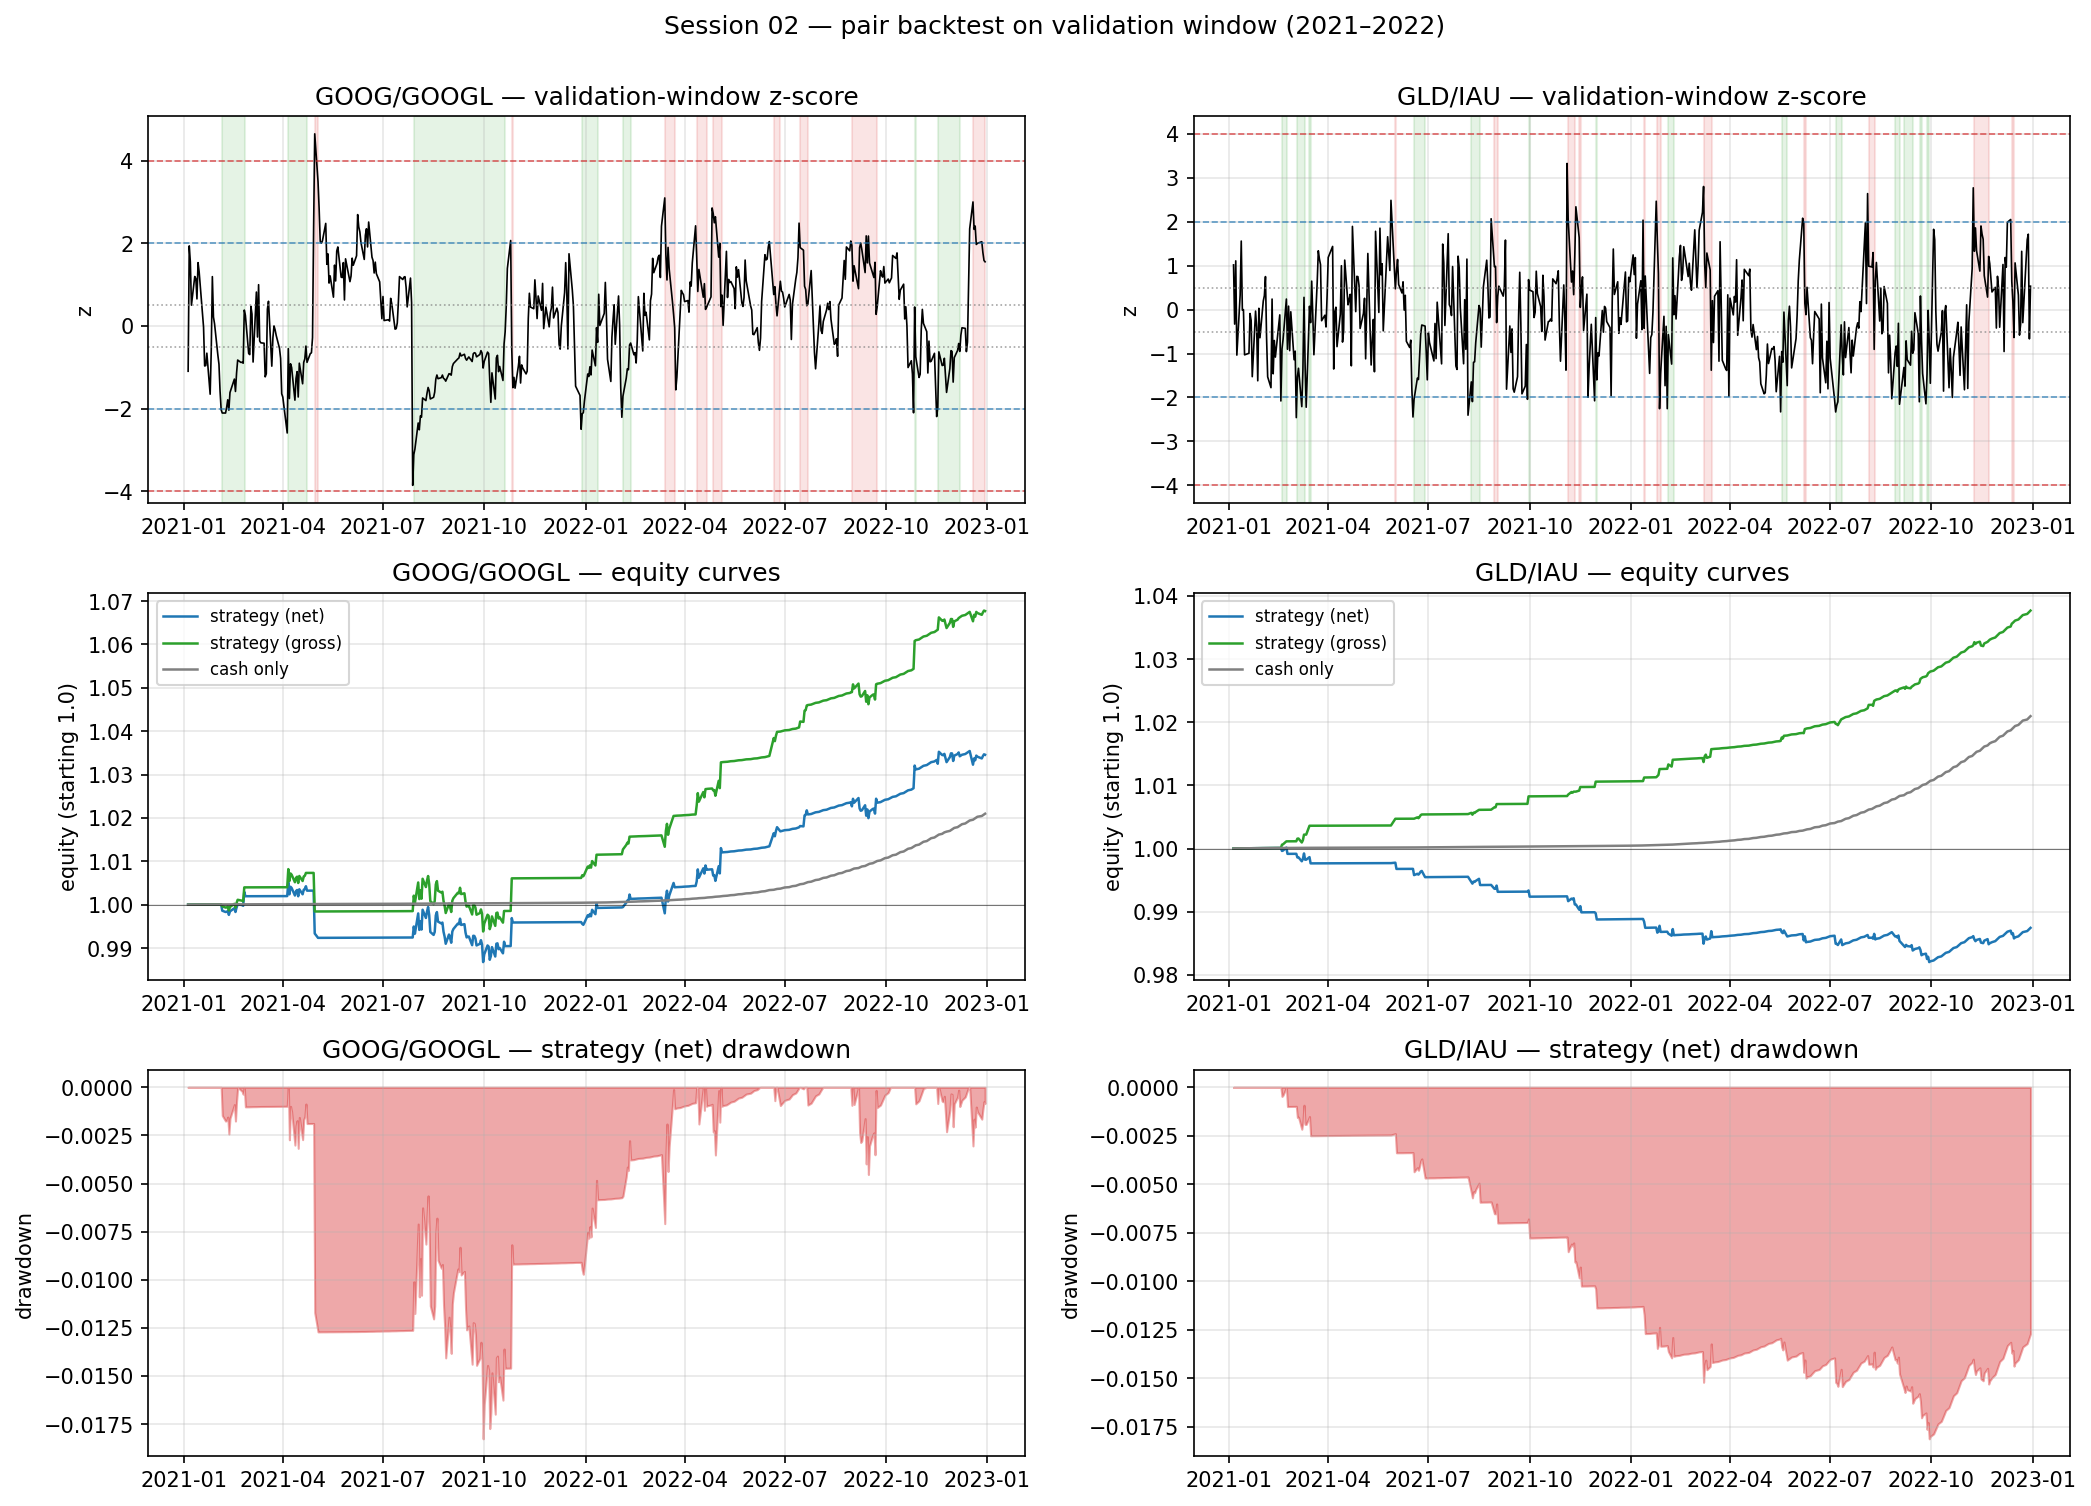

In [6]:
Image(str(RESULTS / '02_pair_backtest.png'))

Reading the figure: rows are z-score with bands and in-position
shading (top), net/gross/cash equity curves (middle), and net-return
drawdown (bottom). Left column GOOG/GOOGL, right column GLD/IAU.
The visual contrast between the two pairs makes the cost story
legible: GOOG/GOOGL takes infrequent positions and accumulates a
small positive equity curve; GLD/IAU takes positions almost
constantly and bleeds a thin steady loss to costs.

### Note on the framework bug (F4)

While reviewing exposure diagnostics from this session we noticed
that on days when both legs were at zero weight, the portfolio
return was *exactly zero* rather than the daily DTB3 rate. This was
a multi-asset cash accrual bug in Backtest-Engine. The fix lives in
Backtest-Engine in a separate commit with a regression test. The
GOOG/GOOGL net Sharpe shown above is the post-fix figure — lower
than the pre-fix figure was. Methodological rigor sometimes buys
smaller numbers.

## 5. Kalman analysis (session 03)

Replace the frozen OLS β with the filtered β from a 2-state Kalman
filter on (α, β). Same pairs, same validation window, same costs —
only the hedge mechanism changes.

In [7]:
kalman_main = kalman_metrics[
    kalman_metrics['method'].isin(['OLS', 'Kalman', 'B&H', 'cash'])
][[
    'pair', 'method', 'half_life', 'sharpe', 'sharpe_gross',
    'ann_return', 'ann_vol', 'max_drawdown', 'turnover_ann',
    'pct_days_active',
]]
kalman_main

,pair,method,half_life,sharpe,sharpe_gross,ann_return,ann_vol,max_drawdown,turnover_ann,pct_days_active
0,GOOG/GOOGL,OLS,25.5311,0.3684,1.2284,0.0174,0.0185,-0.0183,31.6521,0.3367
1,GOOG/GOOGL,Kalman,0.2840,-1.1673,0.7515,-0.0009,0.0097,-0.0171,36.1317,0.0518
2,GOOG/GOOGL,B&H,NaN,0.1575,0.1583,0.0631,0.3224,-0.4460,0.5020,0.9980
3,GOOG/GOOGL,cash,NaN,NaN,NaN,0.0105,0.0009,0.0000,NaN,NaN
4,GLD/IAU,OLS,4.9520,-3.4128,2.7052,-0.0063,0.0049,-0.0181,49.8306,0.1653
5,GLD/IAU,Kalman,0.4833,-3.2991,0.8718,-0.0040,0.0045,-0.0192,33.0520,0.0558
6,GLD/IAU,B&H,NaN,-0.2635,-0.2618,-0.0272,0.1442,-0.2103,0.5020,0.9980
7,GLD/IAU,cash,NaN,NaN,NaN,0.0105,0.0009,0.0000,NaN,NaN


GOOG/GOOGL net Sharpe drops from **+0.37 (OLS)** to **−1.17
(Kalman, default Q)**. This is not a small underperformance — it
is a sign-flipping degradation on the only pair with positive
edge.

The diagnostic block in the script isolates the mechanism through
two tables: a Q-sensitivity sweep and an AR(1) comparison.

In [8]:
q_sweep = kalman_metrics[
    kalman_metrics['method'].str.startswith('Kalman_diag', na=False)
][[
    'method', 'Q_value', 'beta_std_val', 'half_life', 'z_window',
    'pct_days_active', 'sharpe', 'sharpe_gross',
]].rename(columns={
    'method': 'Q',
    'beta_std_val': 'beta_std_val',
    'half_life': 'innov_HL_sel',
    'pct_days_active': 'pct_active',
    'sharpe': 'sharpe_net',
})
q_sweep['Q'] = q_sweep['Q'].str.replace('Kalman_diag_', '', regex=False)
q_sweep

,Q,Q_value,beta_std_val,innov_HL_sel,z_window,pct_active,sharpe_net,sharpe_gross
8,Q=1e-6 (tight),0.0000,0.0022,2.2268,20.0000,0.1155,0.2425,1.4474
9,Q=1e-4 (Chan default),0.0001,0.0026,0.2840,20.0000,0.0518,-1.1673,0.7515
10,Q=1e-2 (loose),0.0100,0.0027,inf,20.0000,0.0478,-0.9779,1.1951


Two facts dominate the sweep. First, the validation-window standard
deviation of the filtered β stays at ~0.002–0.003 across four orders
of magnitude in Q — there is empirically no β drift to track on this
pair. Second, net Sharpe degrades monotonically from OLS as Q grows.
At Q=10⁻⁶ (essentially OLS-equivalent) net Sharpe is +0.24 vs OLS
+0.37; at Chan's default Q=10⁻⁴ it falls to −1.17; at Q=10⁻² it
sits at −0.98. The cost of letting β move at all on this pair is
strictly negative.

The mechanism is visible one level deeper, in the autocorrelation of
the series the strategy is z-scoring. We display the AR(1) table
verbatim from `results/03_kalman_diagnostics.md`:

| Series                                 | AR(1)   |
|----------------------------------------|---------|
| OLS spread (validation)                | +0.96   |
| Kalman innovation, Q=1e-6 (tight)      | +0.75   |
| Kalman innovation, Q=1e-4 (default)    | +0.08   |
| Kalman innovation, Q=1e-2 (loose)      | −0.14   |

The OLS spread on the validation window has AR(1) +0.96, mirroring
the ~25-day half-life from the selection-window fit — a genuine,
persistent mean-reversion structure that the OLS strategy can
trade. At Chan's default Q the Kalman innovation has AR(1) +0.08 —
essentially white noise. This is what the filter is *designed* to
do: the innovation is the part of `y_t` that is not predicted by
the state estimate, so a Kalman filter run on a series with
persistent mean reversion will absorb that persistence into its
state and emit innovations orthogonal to the past. The z-score
strategy then has nothing to trade.

For structurally stable pairs the Kalman filter is not an upgrade
to OLS — it is an adaptiveness penalty proportional to Q, with no
drift to compensate.

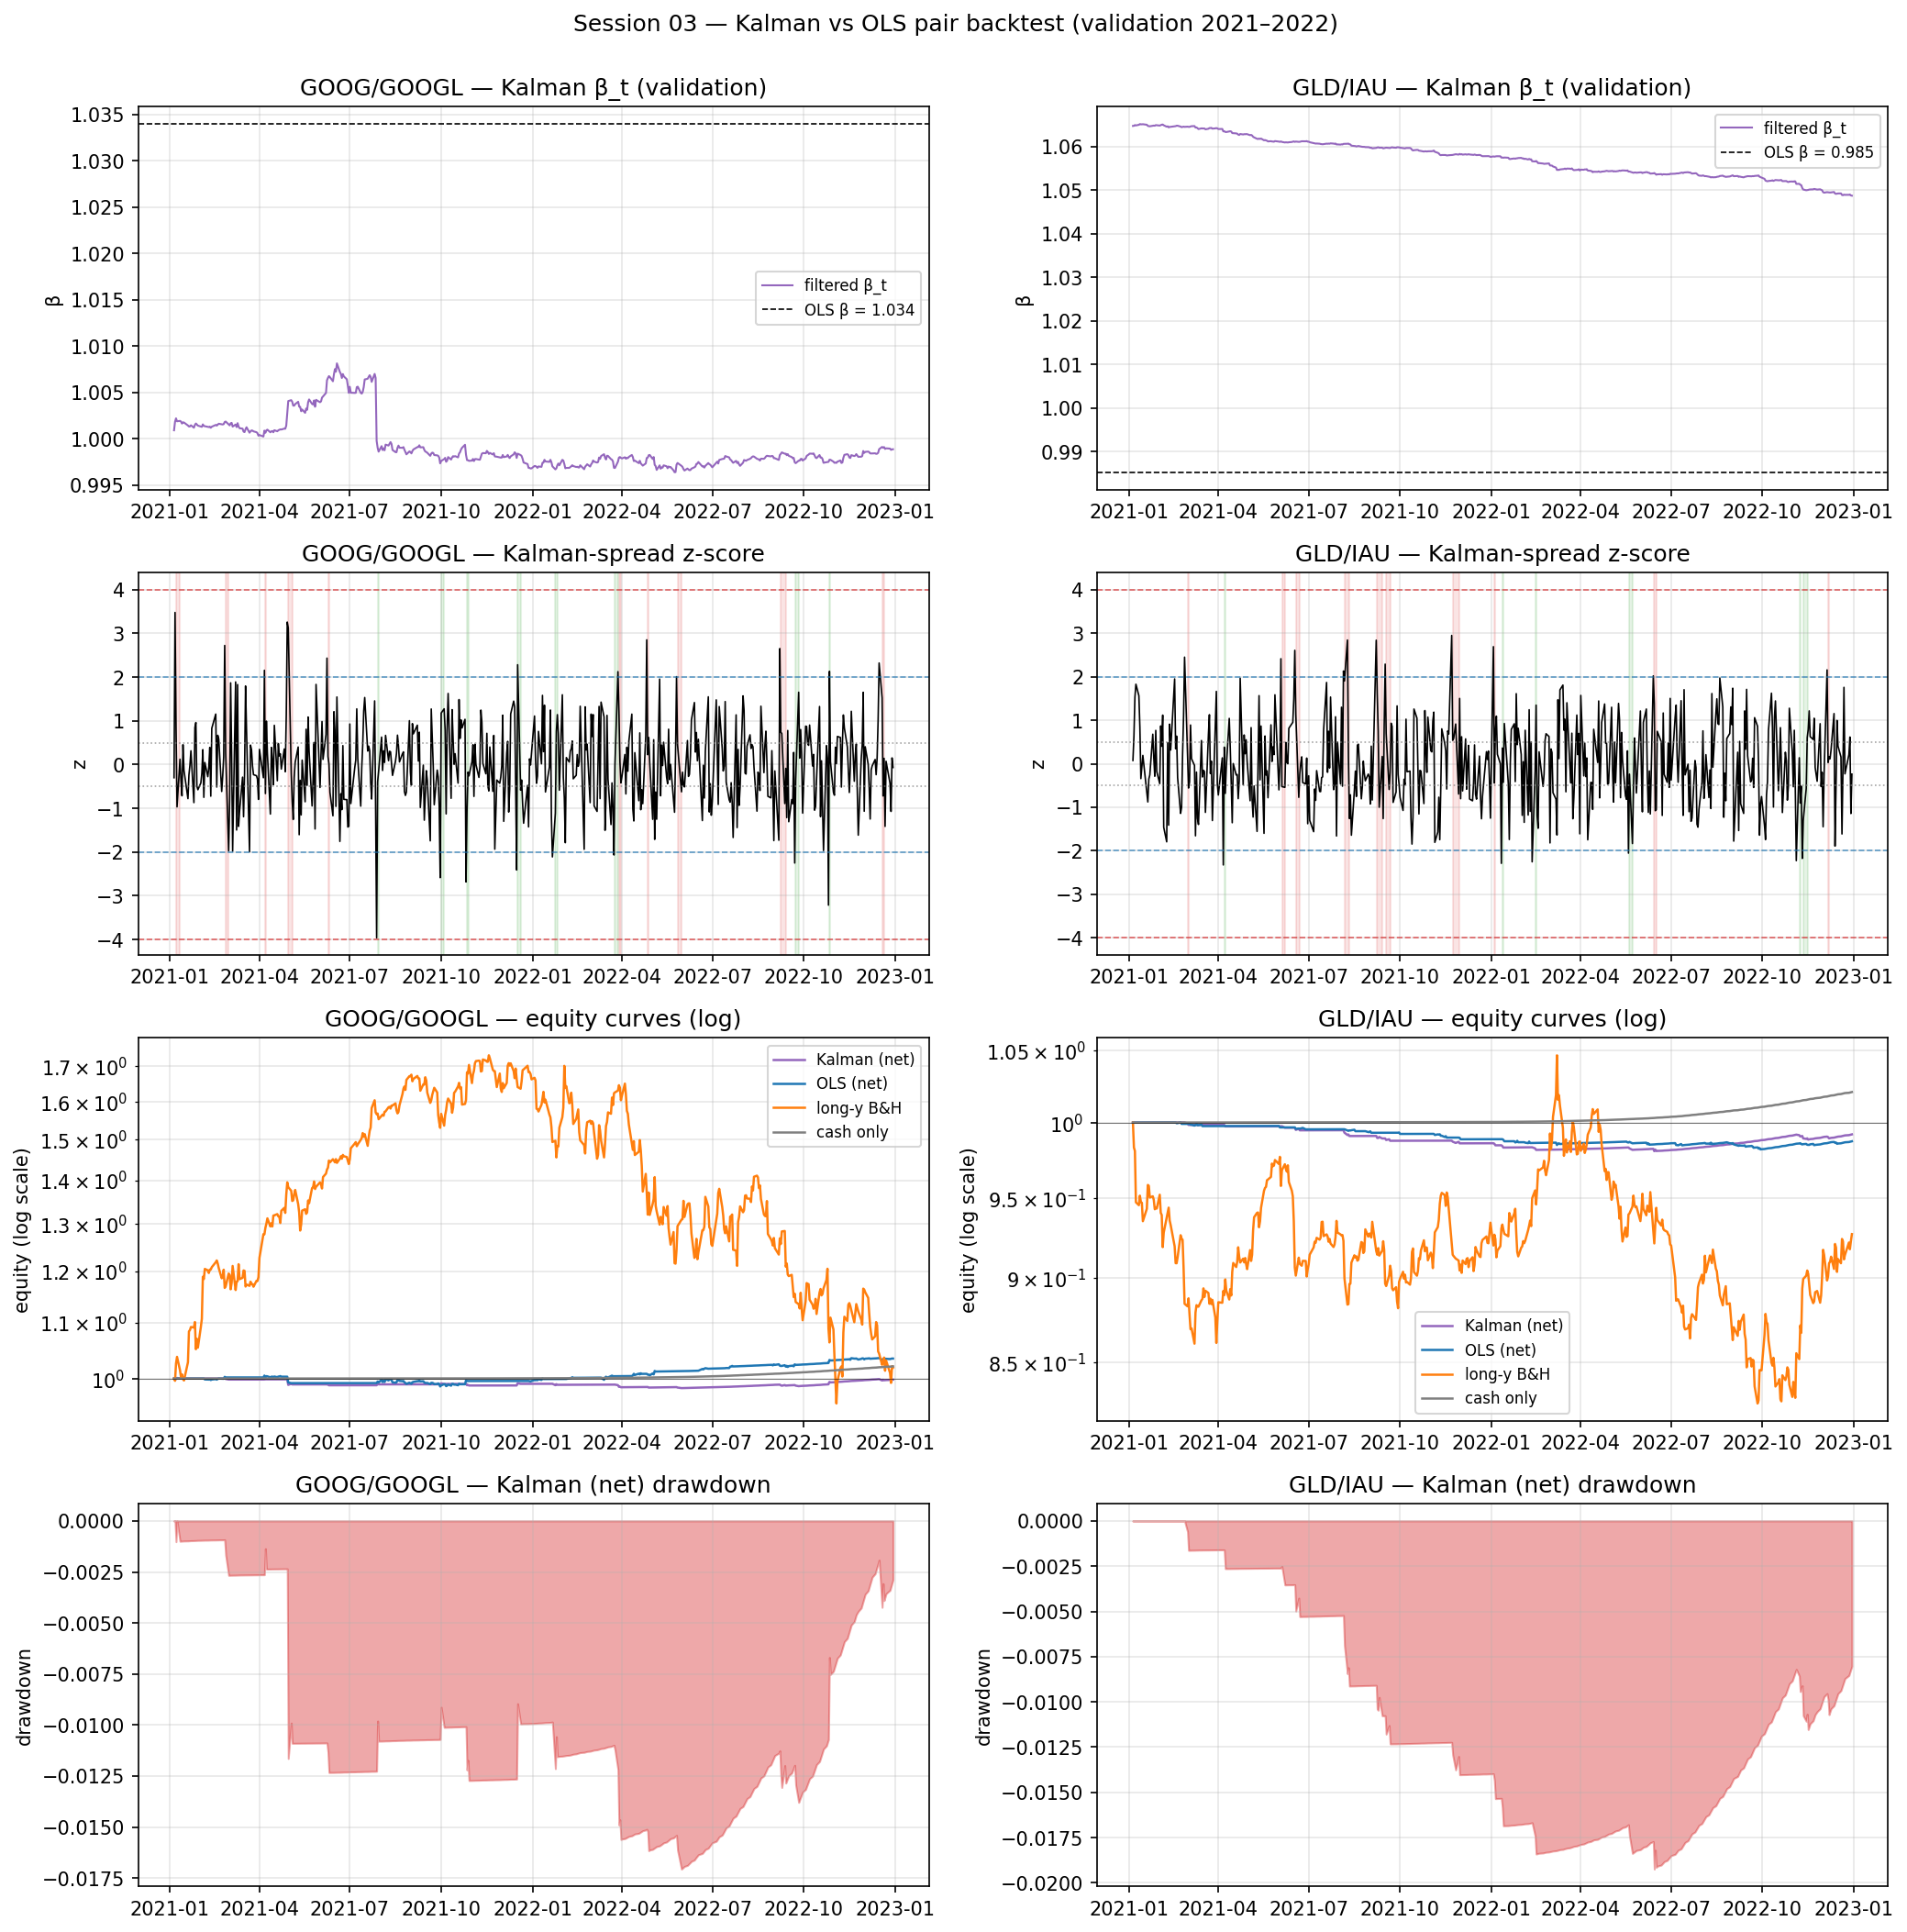

In [9]:
Image(str(RESULTS / '03_kalman_pair_backtest.png'))

Reading the figure: top row is the filtered β over the validation
window with the OLS reference (dashed) — the variation is well
under 1% of β. Second row is the Kalman z-score; third row is the
equity curves (Kalman vs OLS vs long-y B&H vs cash, log scale);
bottom row is the Kalman drawdown. The OLS equity curve climbs
modestly; the Kalman curve drifts down.

## 6. Portfolio of pairs (session 04)

Combine four pair strategies into a single portfolio under three
weighting schemes. Pair set: GOOG/GOOGL (strong evidence), GLD/IAU
and SIVR/SLV (Johansen-only structural pairs), GOOGL/MSFT (the only
new FDR-significant pair from an expanded scan, on weak evidence).
Schemes: equal, inverse-vol, prefer-slow.

In [10]:
portfolio_view = portfolio_metrics[[
    'pair_or_strategy', 'kind', 'weighting', 'evidence_tier',
    'sharpe', 'sharpe_gross', 'ann_return', 'max_drawdown',
    'turnover_ann', 'pct_days_active',
]]
portfolio_view

,pair_or_strategy,kind,weighting,evidence_tier,sharpe,sharpe_gross,ann_return,max_drawdown,turnover_ann,pct_days_active
0,GOOG/GOOGL,individual_pair,NaN,strong,0.3684,1.2284,0.0174,-0.0183,31.6521,0.3367
1,GLD/IAU,individual_pair,NaN,structural-johansen-only,-3.4128,2.7052,-0.0063,-0.0181,49.8306,0.1653
2,GOOGL/MSFT,individual_pair,NaN,weak-eg-passing,-1.0189,-1.0010,-0.1319,-0.2718,5.4358,0.5478
3,SIVR/SLV,individual_pair,NaN,structural-johansen-only,-1.3673,2.5704,0.0021,-0.0097,46.3635,0.1374
4,PORTFOLIO,portfolio,equal,NaN,-1.2863,-0.8228,-0.1325,-0.2621,109.9703,0.7709
5,PORTFOLIO,portfolio,inverse_vol,NaN,-1.3957,-0.6961,-0.1322,-0.2567,152.5586,0.7709
6,PORTFOLIO,portfolio,prefer_slow,NaN,-0.9892,-0.7984,-0.1166,-0.2401,51.8055,0.7271
7,SPY,benchmark,NaN,NaN,0.1941,0.1953,0.0493,-0.2450,0.5020,0.9980
8,CASH,benchmark,NaN,NaN,NaN,NaN,0.0105,0.0000,NaN,NaN


Best individual pair Sharpe (GOOG/GOOGL): **+0.37**. Best portfolio
Sharpe (prefer-slow): **−0.99**. The portfolio underperforms the
best single component by ~1.4 in Sharpe units across all three
weighting schemes.

The pairwise correlation of pair net returns is essentially zero
across all combinations — by the textbook intuition this is exactly
the regime where diversification should help. It does not, because
diversification redistributes risk across components but cannot
manufacture edge. With three of four candidates carrying
negative-Sharpe edges, no allocation rule can average them into a
winner. The portfolio drawdown is in fact deeper than any single
pair's.

Inverse-vol deserves a separate note. It assigned its largest
weight to GLD/IAU because that pair has the lowest realised σ —
but GLD/IAU is the cost-destroyed pair. Low realised volatility is
not the same as high signal quality; it can simply reflect small
return magnitudes, including small *negative* return magnitudes.
Inverse-vol at this scale is an active bet that the lowest-σ pair
has the highest unobserved edge.

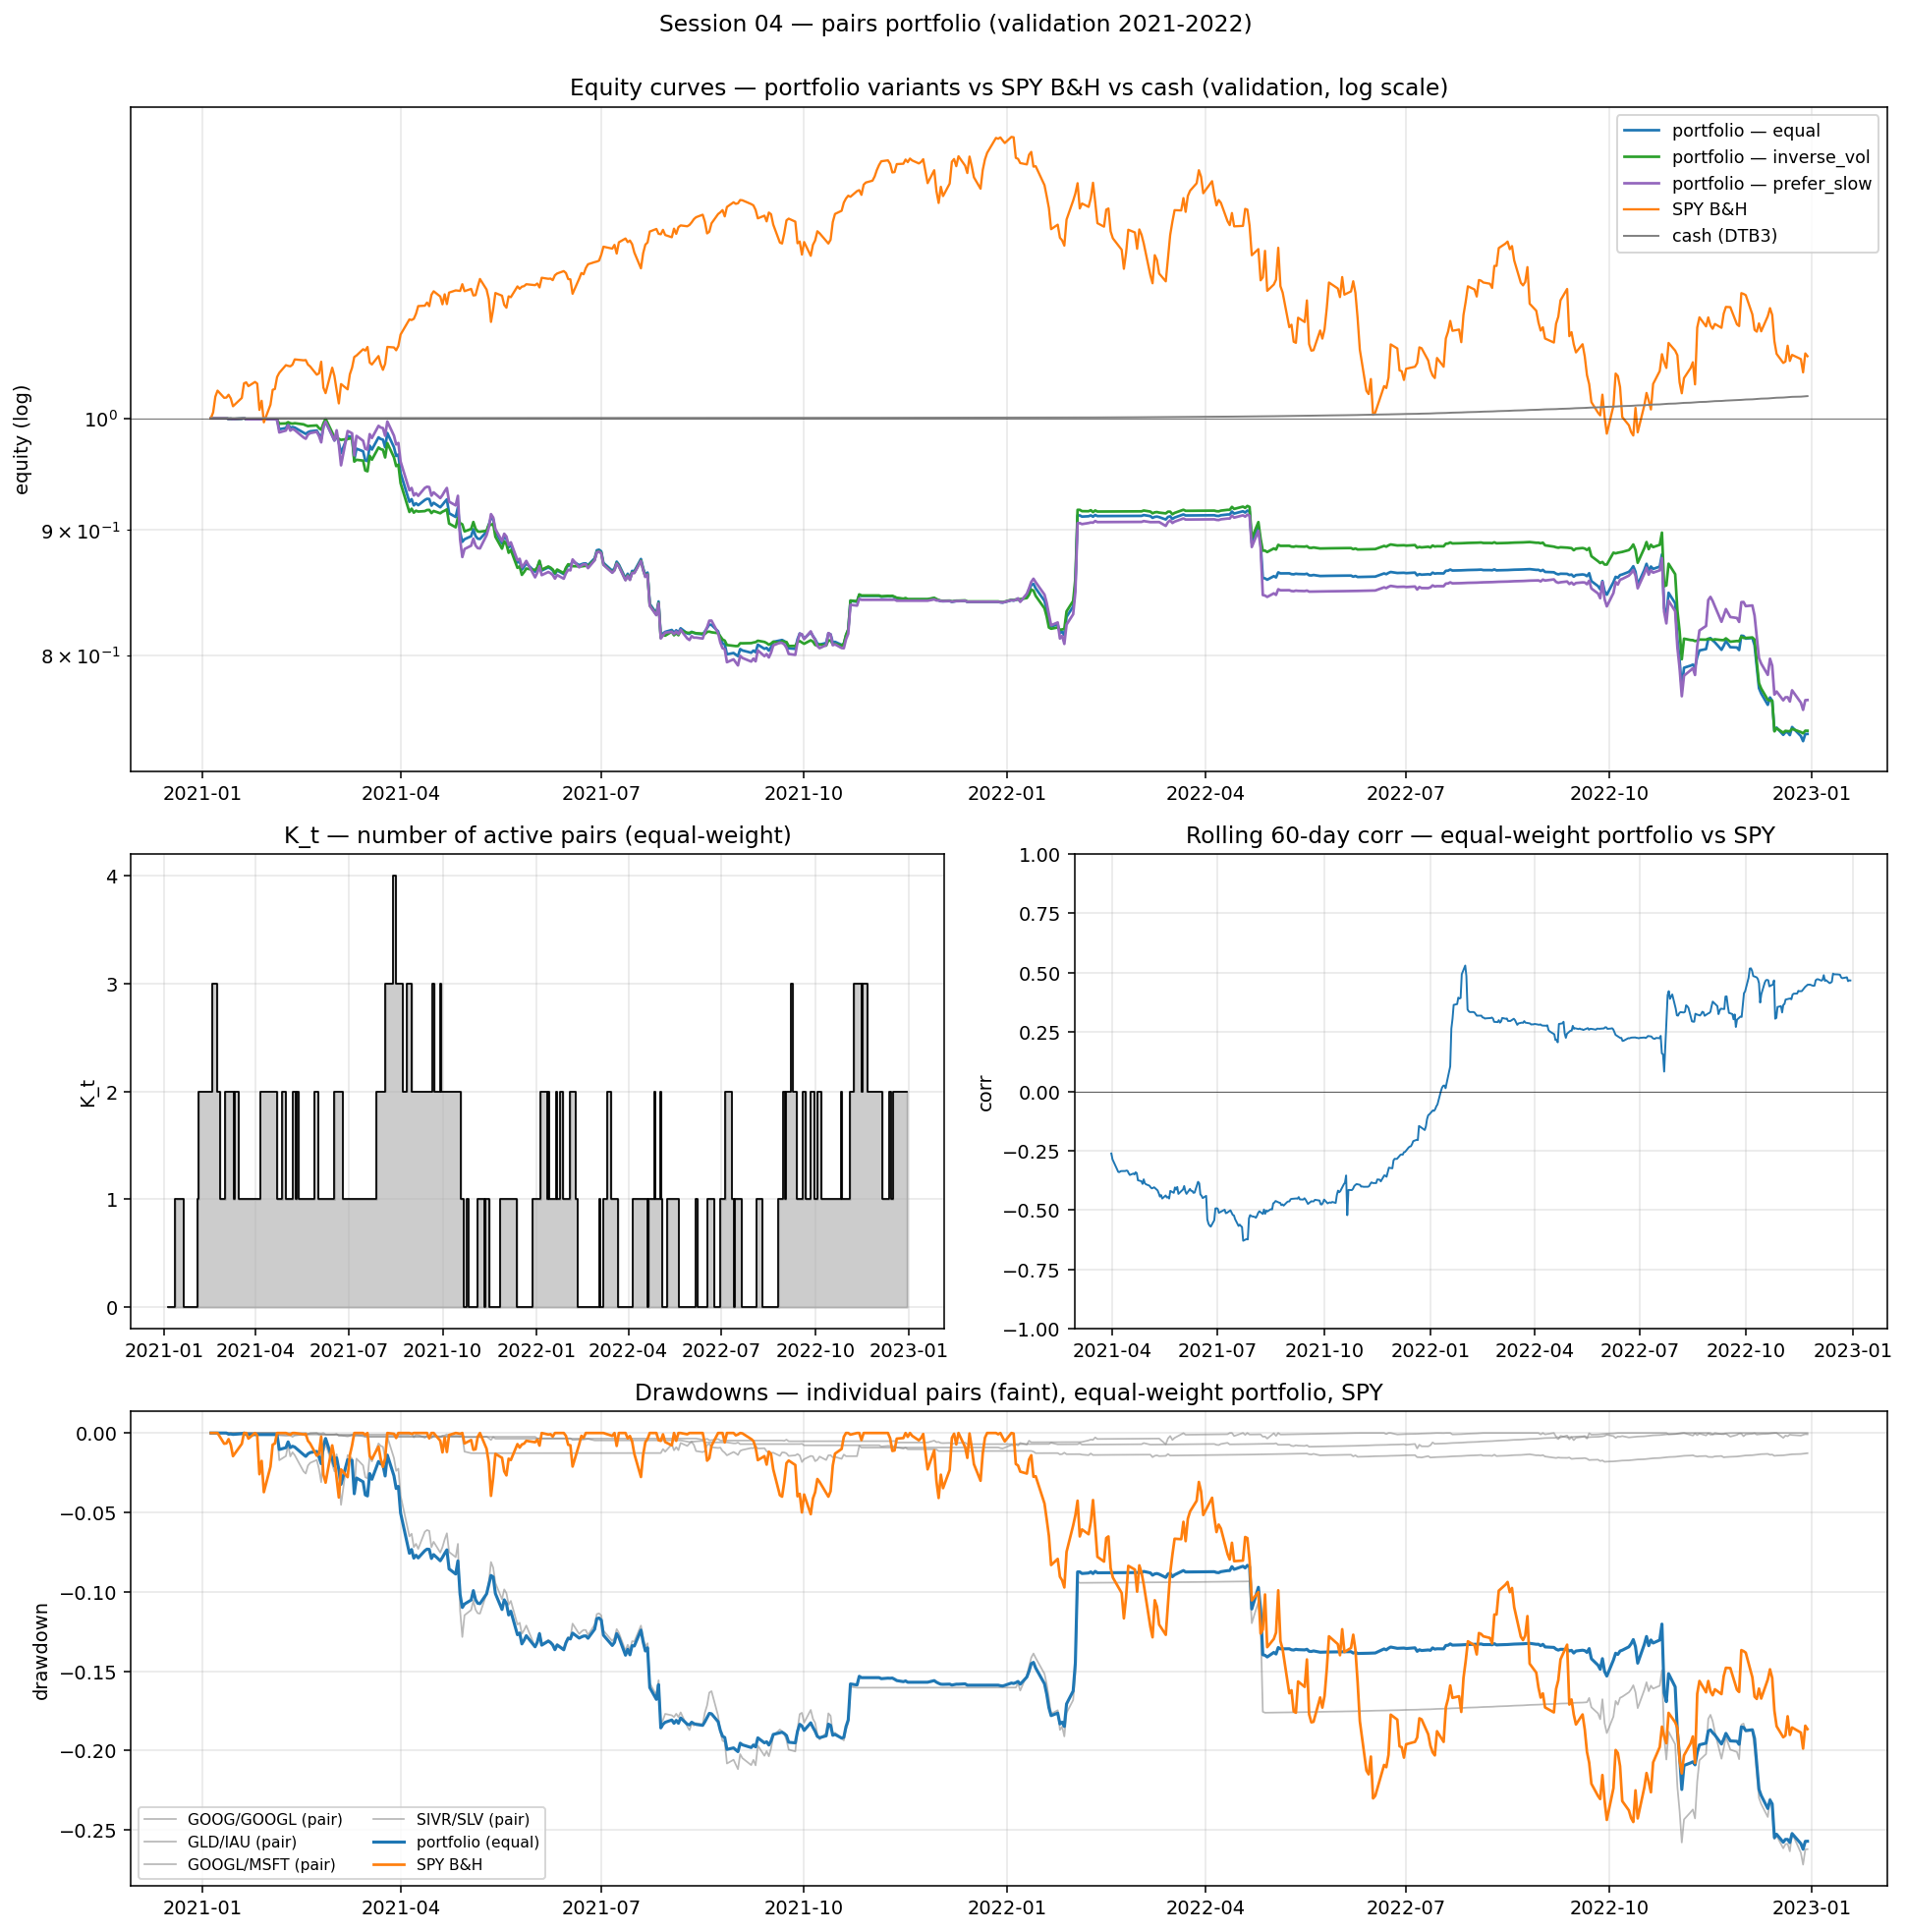

In [11]:
Image(str(RESULTS / '04_pairs_portfolio.png'))

Reading the figure: the top panel shows three portfolio equity
curves (equal, inverse-vol, prefer-slow) against SPY B&H and cash —
all three portfolios trail cash. The middle-left panel shows K_t,
the count of active pairs over the validation window. The middle-
right panel is the rolling 60-day correlation of the equal-weight
portfolio with SPY (oscillates around zero). The bottom panel is
the drawdown of each individual pair (faint) overlaid on the
equal-weight portfolio (bold) and SPY (orange) — the equal-weight
portfolio's drawdown is deeper than any single component.

## 7. Synthesis and what's next

Considered together, the six findings support a cautious reading.
F1 reproduces the post-2003 finding that single-stock pairs trading
on US large caps does not survive multiple-testing correction. F2
verifies that the pipeline is not over- or under-rejecting by
construction. F3 produces a small honest positive number on a
share-class arb. F4 lowers that number by fixing a bug in our own
infrastructure. F5 fails to improve on F3 with a more sophisticated
hedge model and identifies the mechanism precisely. F6 fails to
improve on F3 by portfolio construction, again with a clean
mechanism.

The picture is consistent: there is residual edge in pairs that
share an actual underlying claim (share classes, co-listings, ADRs),
and approximately none in pairs that share only a statistical
relationship. Sophistication does not rescue weak edges; it usually
makes them worse, in ways the diagnostics make legible.

**Next step.** The 2023–2024 holdout window is reserved. The natural
next step is a single end-of-project run of the surviving GOOG/GOOGL
OLS strategy on that window. Other directions worth pursuing:
international dual-listings and ADR/local pairs (universes where
structural cointegration arguably still survives at scale), more
sophisticated cost models, and higher-frequency variants where the
fast-pair-cost-destruction trade-off changes.

For deeper detail, see `docs/writeup.md`. For source code, the
library lives under `src/pairs_trading/` and the runnable entry
points under `scripts/`.